# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Source Modelling**<center>

In [8]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
import matplotlib.pyplot as plt

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

plt.rcdefaults()

RCPARAMS = {
    'axes.formatter.limits': (-3, 3),
    'savefig.bbox': 'tight',
}
mpl.rcParams.update(RCPARAMS)
ds.show.set_figures_darkbkg()

In [36]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "baseline_2-50keV_1ks"

RUN_ID: str = 'GC_rec_1ks_2-6keV'
E_min, E_max = 2.0, 6.0           # [keV]
DATASET: str = 'reconstructed'

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

ID_CAMERA_A: str = "cam1a"
# ID_CAMERA_B: str = "cam1b"

In [37]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y, hide_bulk_els_y=1.5)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
# sdlB = ds.get_data(filepaths[ID_CAMERA_B]["reconstructed"], E_min=E_min, E_max=E_max)
# catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, _ = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


In [38]:
detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

UserInfo: using bulk mask of [0.0 x 1.5] mm.


In [39]:
def set_phase(x: NDArray) -> NDArray:
    """Centers x values around zero."""
    return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
def find_tick_val(ticks: NDArray, trg_vals: NDArray, atol: float = 1e-2) -> NDArray:
    """Finds the idxs inside `ticks` relative to given values `trg_vals`."""
    trg_idxs: list[int] = []
    for v in trg_vals:
        idx = np.argwhere(np.isclose(ticks, v, atol=atol))
        if idx.size > 0: trg_idxs.append(idx[0, 0])
    return np.array(trg_idxs)

def show_SPSF(
    camera: CodedMaskCamera,
    srcID: str,
    psf: NDArray,
    modelled: NDArray,
    save_to: str | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Plots the SPSF heat maps and profiles along fine/coarse axes + cfr with modelled source.
    """
    title_fs = 16
    lbl_fs = 14
    # setup
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    residues = (psf - modelled) * 100 / psf.max()
    n, m = psf.shape
    xslice, yslice = zip(
        *tuple((c[(n - 1) // 2, :], c[:, (m - 1) // 2]) for c in (psf, modelled, residues))
    )
    slice_clrs = ('Orange', 'DeepSkyBlue')
    # plot figure
    fig, axs = plt.subplots(2, 3, tight_layout=True, **fig_kws)
    axs = axs.flatten()
    
    # ------------------------ SPFS HEAT MAPS ------------------------
    img_layout = {'origin': 'lower', 'interpolation': 'none', 'aspect': 2 * m / n}
    yticks, xticks = map(lambda s: np.arange(0, s), psf.shape)
    _ytick_lbls, _xtick_lbls = (
        dty / 60 * (yticks - len(yticks) // 2), dtx * (xticks - len(xticks) // 2),
    )
    yticks_ = find_tick_val(_ytick_lbls, np.array([-5.0, -2.5, 0.0, 2.5, 5.0]), atol=7e-2)
    yticks_lbl = [float(f'{t:.1f}') for t in _ytick_lbls[yticks_]]
    xticks_ = find_tick_val(_xtick_lbls, np.array([-6.35, 0.0, 6.35]), atol=1e-3)
    xticks_lbl = [float(f'{t:.1f}') for t in _xtick_lbls[xticks_]]

    axs[0].set_title(f'{srcID} SPFS', fontsize=title_fs)
    psf_img = axs[0].imshow(psf, cmap='gist_heat', **img_layout)
    cbar = fig.colorbar(psf_img, ax=axs[0], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('counts [ph]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[0].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[0].set_ylabel(ylabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    axs[3].set_title(f'{srcID} SPFS Residues', fontsize=title_fs)
    mod_img = axs[3].imshow(residues, **img_layout)
    cbar = fig.colorbar(mod_img, ax=axs[3], location='right', shrink=0.8, pad=0.05)
    cbar.set_label('residues counts [%]', fontsize=lbl_fs)
    cbar.ax.tick_params(labelsize=lbl_fs)
    axs[3].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[3].set_ylabel(ylabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)

    for idx in [0, 3]:
        axs[idx].set_xticks(xticks_, xticks_lbl)
        axs[idx].set_yticks(yticks_, yticks_lbl)

    # ------------------------ SPFS PROFILES | FINE AXIS ------------------------
    x = dtx * set_phase(xslice[0])

    axs[1].set_title('SPFS Slice - Fine Axis', fontsize=title_fs)
    axs[1].stairs(xslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[1].stairs(xslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[1].set_ylim(-3e4, None)
    axs[1].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[1].yaxis.tick_right()

    axs[4].set_title('SPFS Slice Residues - Fine Axis', fontsize=title_fs)
    axs[4].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[4].stairs(xslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[4].set_xlabel(xlabel='$\\theta_{fine}$ [arcmin]', fontsize=lbl_fs)
    axs[4].yaxis.tick_right()

    # ------------------------ SPFS PROFILES | COARSE AXIS ------------------------
    x = dty * set_phase(yslice[0]) / 60

    axs[2].set_title('SPFS Slice - Coarse Axis', fontsize=title_fs)
    axs[2].stairs(yslice[0], edges=x, edgecolor=slice_clrs[0], label='true')
    axs[2].stairs(yslice[1], edges=x, edgecolor=slice_clrs[1], label='modelled')
    # axs[2].set_ylim(-3e4, None)
    axs[2].set_xlabel(xlabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[2].set_ylabel(ylabel='counts [ph]', labelpad=10, fontsize=lbl_fs)
    axs[2].yaxis.set_label_position('right')
    axs[2].yaxis.tick_right()

    axs[5].set_title('SPFS Slice Residues - Coarse Axis', fontsize=title_fs)
    axs[5].plot(x, np.zeros_like(x), slice_clrs[0], label='ground', linestyle='--', alpha=0.6)
    axs[5].stairs(yslice[2], edges=x, edgecolor=slice_clrs[1], label='residues')
    axs[5].set_xlabel(xlabel='$\\theta_{coarse}$ [deg]', fontsize=lbl_fs)
    axs[5].set_ylabel(ylabel=r'residues counts [%]', labelpad=10, fontsize=lbl_fs)
    axs[5].yaxis.set_label_position('right')
    axs[5].yaxis.tick_right()


    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5, labelsize=lbl_fs)
    for idx in [1, 2, 4, 5]:
        axs[idx].legend(loc='best')

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    
    plt.show()
    return

In [42]:
from bloodmoon.images import argmax
from darksun.data import Log

def subtract_previous(
    camera: CodedMaskCamera,
    log: Log,
    src_idx: int,
    true: NDArray,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Subtracts sources previous to IROS src index in `log`."""
    sky = true.copy()
    for idx in range(src_idx):
        modelled = model_sky(
            camera, log.log['shift_x'][idx], log.log['shift_y'][idx],
            log.log['fluence'][idx], vignetting=vignetting, psfy=psfy
        )
        sky -= modelled
    return sky

def find_boxmax(sky: NDArray, centre: tuple[int, int], boxsize: int = 5) -> tuple[int, int]:
    """Finds the argmax of given sky in a box centered around `pos`."""
    rcut, ccut = map(lambda idx: slice(idx - boxsize, idx + boxsize + 1), centre)
    p, q = centre
    n, m = argmax(sky[rcut, ccut])
    return p - boxsize + n, q - boxsize + m




IDX: int = 0

base_sky = subtract_previous(wfm, logA, IDX, true_skyA, VIGNETTING, PSFY)
SRC_DATA = {
    'sx': logA.log['shift_x'][IDX],
    'sy': logA.log['shift_y'][IDX],
    'cts': logA.log['fluence'][IDX],
    'pos': find_boxmax(base_sky, (logA.log['y'][IDX], logA.log['x'][IDX])),
    'crp': (40, 5),
}

template = model_sky(wfm, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], vignetting=VIGNETTING, psfy=PSFY)
src_psf, src_model = map(lambda x: ds.crop(x, SRC_DATA['pos'], SRC_DATA['crp']), (base_sky, template))

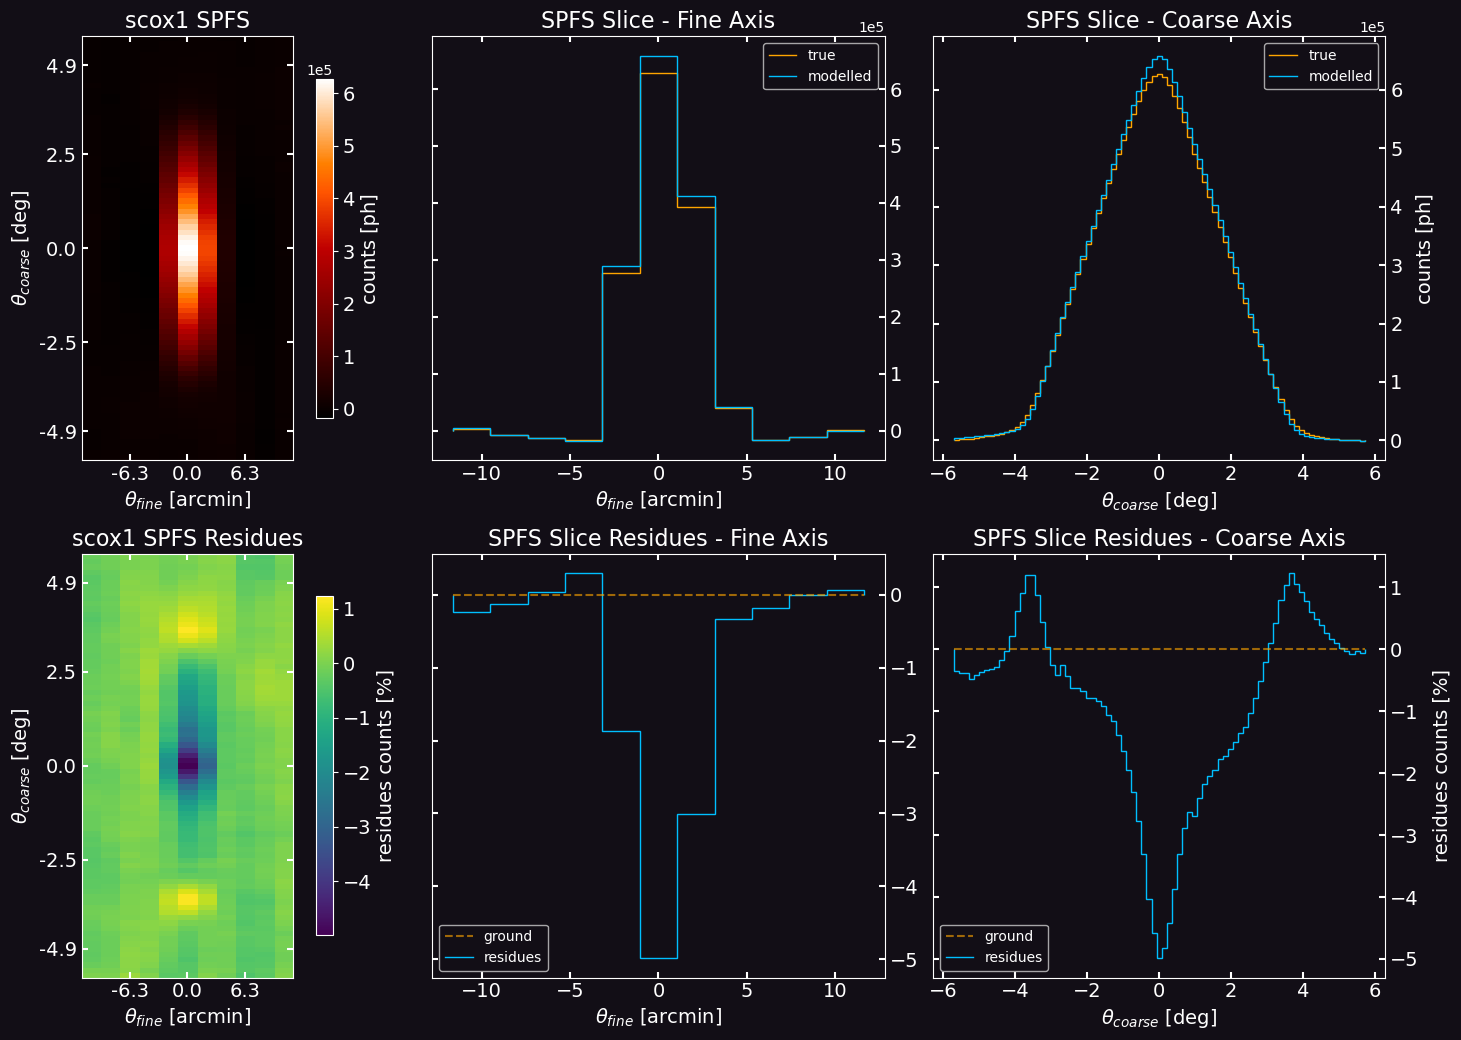

In [43]:
show_SPSF(
    camera=wfm,
    srcID=logA.log['ID'][IDX],
    psf=src_psf,
    modelled=src_model,
    # save_to=f'{OUT_RESULTS_PATH}/Crab_1ks_{E_min}-{E_max}keV.pdf',
    figsize=(5 * 3 + 0.5, 5 * 2 + 0.5),
)